# Full CIFAR-10 ResNet-18 W4 layer sensitivity and W4-versus-W8 comparison

This notebook repeats Notebook 17's complete ResNet-18 experiment at **4-bit weight precision** for both custom per-channel PTQ and custom scalar codebook quantization. Every accuracy and disagreement result uses all **10,000 official CIFAR-10 test images**.

The final section loads Notebook 17's saved 8-bit CSV files and creates exact tensor-by-tensor W4-versus-W8 comparison tables and figures. Only the selected kernel is quantized during an isolated layer experiment; all remaining model weights and all activations remain FP32. No retraining or fake-quantization nodes are used.

In [1]:
from pathlib import Path
import gc, json, platform, sys, time

import keras
import keras_hub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.stats import binomtest, pearsonr, spearmanr
import tensorflow as tf

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("Run this notebook from the project root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models import CIFAR10_CLASS_NAMES
from src.quantization.custom_quantization import (
    codebook_vectorize_model_n_bits, custom_ptq_n_bits, dequantize_tensor,
    reconstruct_codebook_tensor,
)

print(f"Python: {sys.version.split()[0]} ({sys.executable})")
print(f"TensorFlow: {tf.__version__}; Keras: {keras.__version__}; SciPy: {scipy.__version__}")
print(f"Hardware: {platform.platform()}")

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.13.7 (/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/bin/python)
TensorFlow: 2.20.0; Keras: 3.14.1; SciPy: 1.18.0
Hardware: macOS-26.5.2-arm64-arm-64bit-Mach-O


## 1. Fixed 4-bit experimental configuration

The codebook contains $K=2^4=16$ FP32 centroids per selected tensor. With `vector_dim=1`, every scalar assignment costs four theoretically packed bits before codebook overhead.

In [2]:
MODEL_PATH = PROJECT_ROOT / "artifacts" / "resnet18_cifar10_training" / "resnet18_cifar10_fp32.keras"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "resnet18_4bit_layer_sensitivity"
EIGHT_BIT_OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "resnet18_full_layer_sensitivity"
NUM_BITS = 4
CODEBOOK_SIZE = 2 ** NUM_BITS
CACHE_VERSION = "v1_w4_per_channel_vs_k16_scalar_full_test"
CACHE_DIR = OUTPUT_DIR / "cache" / CACHE_VERSION
PREDICTION_CACHE_DIR = CACHE_DIR / "predictions"
RECONSTRUCTION_CACHE_DIR = CACHE_DIR / "reconstructed_weights"

NUM_TEST_IMAGES = 10_000
BATCH_SIZE = 32
QUANTIZE_MIN_RANK = 2
PTQ_PER_CHANNEL = True
CODEBOOK_VECTOR_DIM = 1
CODEBOOK_DTYPE = np.float32
CODEBOOK_ITERATIONS = 30
CODEBOOK_MAX_SAMPLES = 100_000
RANDOM_SEED = 42
BOOTSTRAP_REPETITIONS = 2_000
TOP_K_VALUES = (1, 3, 5)
RANDOM_CONTROL_REPETITIONS = 10
FORCE_RECOMPUTE = False

METHODS = {
    "ptq_w4": "Custom per-channel 4-bit PTQ",
    "codebook_w4": "Custom scalar codebook W4 (K=16)",
}
METHOD_FAMILY = {"ptq_w4": "ptq", "codebook_w4": "codebook"}

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing trained model: {MODEL_PATH}. Run notebook 06 first.")
for directory in (OUTPUT_DIR, PREDICTION_CACHE_DIR, RECONSTRUCTION_CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_SEED); tf.random.set_seed(RANDOM_SEED)
print(f"Checkpoint: {MODEL_PATH}")
print(f"Output: {OUTPUT_DIR}")
print(f"Comparison source: {EIGHT_BIT_OUTPUT_DIR}")
print(f"Bits: {NUM_BITS}; codebook K: {CODEBOOK_SIZE}; required test images: {NUM_TEST_IMAGES:,}")

Checkpoint: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_cifar10_training/resnet18_cifar10_fp32.keras
Output: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_4bit_layer_sensitivity
Comparison source: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_full_layer_sensitivity
Bits: 4; codebook K: 16; required test images: 10,000


## 2. Load the immutable checkpoint and complete CIFAR-10 test set

In [3]:
model = keras.models.load_model(MODEL_PATH, compile=False)
(_, _), (test_images, test_labels) = keras.datasets.cifar10.load_data()
test_labels = test_labels.reshape(-1).astype(np.int32)
assert len(test_images) == len(test_labels) == NUM_TEST_IMAGES, (
    f"Expected all {NUM_TEST_IMAGES:,} test images; received {len(test_images):,}."
)
image_converter = keras_hub.layers.ResNetImageConverter(
    image_size=(224, 224),
    scale=[0.017124753831663668, 0.01750700280112045, 0.017429193899782133],
    offset=[-2.1179039301310043, -2.0357142857142856, -1.8044444444444445],
    interpolation="bicubic", crop_to_aspect_ratio=True,
)
def preprocess_images(images):
    return image_converter(images)

baseline_weights = [weight.numpy() for weight in model.weights]
fp32_parameter_bytes = int(sum(values.nbytes for values in baseline_weights))
print(f"Loaded all {len(test_images):,} CIFAR-10 test images.")
print(f"FP32 parameter storage: {fp32_parameter_bytes / 1024**2:.2f} MiB")
model.summary(expand_nested=True)

Loaded all 10,000 CIFAR-10 test images.
FP32 parameter storage: 42.69 MiB


Model: "resnet18_cifar10_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ images (InputLayer)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_net_backbone                │ (None, 7, 7, 512)      │    11,186,112 │
│ (ResNetBackbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer (InputLayer)   │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_pad (ZeroPadding2D)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_conv (Conv2D)        │ (None, None, None, 64) │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_bn                   │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_relu (Activation)    │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ pool1_pad (ZeroPadding2D)  │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ pool1_pool (MaxPooling2D)  │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_1_conv       │ (None, None, None, 64) │        36,864 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_1_bn         │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_1_relu       │ (None, None, None, 64) │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_2_conv       │ (None, None, None, 64) │        36,864 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_2_bn         │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_add (Add)    │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_out          │ (None, None, None, 64) │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block1_1_conv       │ (None, None, None, 64) │        36,864 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block1_1_bn         │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block1_1_relu       │ (None, None, None, 64) │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 11,191,242 (42.69 MB)

 Trainable params: 11,181,642 (42.65 MB)

 Non-trainable params: 9,600 (37.50 KB)

## 3. Establish the same tensor coverage as Notebook 17

In [4]:
candidate_rows = []
for weight_index, (weight, values) in enumerate(zip(model.weights, baseline_weights)):
    if np.issubdtype(values.dtype, np.floating) and values.ndim >= QUANTIZE_MIN_RANK:
        tensor_name = getattr(weight, "path", weight.name)
        candidate_rows.append({
            "tensor_index": len(candidate_rows), "weight_index": weight_index,
            "tensor": tensor_name, "layer": tensor_name.rsplit("/", 1)[0],
            "layer_type": "Conv2D" if values.ndim == 4 else "Dense" if values.ndim == 2 else f"rank-{values.ndim}",
            "shape": tuple(values.shape), "parameter_count": int(values.size),
            "fp32_bytes": int(values.nbytes),
        })
candidate_table = pd.DataFrame(candidate_rows)
candidate_names = candidate_table.tensor.tolist()
candidate_by_name = candidate_table.set_index("tensor").to_dict(orient="index")
assert len(candidate_names) == len(set(candidate_names))
print(f"Common eligible tensors: {len(candidate_table)}")
print(f"Common eligible values: {candidate_table.parameter_count.sum():,}")
display(candidate_table)

Common eligible tensors: 21
Common eligible values: 11,172,032


,tensor_index,weight_index,tensor,layer,layer_type,shape,parameter_count,fp32_bytes
0,0,0,conv1_conv/kernel,conv1_conv,Conv2D,"(7, 7, 3, 64)",9408,37632
1,1,5,stack0_block0_1_conv/kernel,stack0_block0_1_conv,Conv2D,"(3, 3, 64, 64)",36864,147456
2,2,10,stack0_block0_2_conv/kernel,stack0_block0_2_conv,Conv2D,"(3, 3, 64, 64)",36864,147456
3,3,15,stack0_block1_1_conv/kernel,stack0_block1_1_conv,Conv2D,"(3, 3, 64, 64)",36864,147456
4,4,20,stack0_block1_2_conv/kernel,stack0_block1_2_conv,Conv2D,"(3, 3, 64, 64)",36864,147456
5,5,25,stack1_block0_1_conv/kernel,stack1_block0_1_conv,Conv2D,"(3, 3, 64, 128)",73728,294912
6,6,30,stack1_block0_0_conv/kernel,stack1_block0_0_conv,Conv2D,"(1, 1, 64, 128)",8192,32768
7,7,31,stack1_block0_2_conv/kernel,stack1_block0_2_conv,Conv2D,"(3, 3, 128, 128)",147456,589824
8,8,40,stack1_block1_1_conv/kernel,stack1_block1_1_conv,Conv2D,"(3, 3, 128, 128)",147456,589824
9,9,45,stack1_block1_2_conv/kernel,stack1_block1_2_conv,Conv2D,"(3, 3, 128, 128)",147456,589824


## 4. Resumable inference and quantization helpers

In [5]:
evaluation_model = keras.models.load_model(MODEL_PATH, compile=False)

def predict_logits(keras_model, raw_images, batch_size=BATCH_SIZE):
    batches = []
    for start in range(0, len(raw_images), batch_size):
        batch = preprocess_images(raw_images[start:start + batch_size])
        batches.append(keras_model(batch, training=False).numpy())
    return np.concatenate(batches).astype(np.float32)

def prediction_cache_path(tag):
    return PREDICTION_CACHE_DIR / f"{tag}.npz"

def evaluate_weights(tag, weights):
    path = prediction_cache_path(tag)
    if path.exists() and not FORCE_RECOMPUTE:
        with np.load(path) as cached:
            logits, predictions = cached["logits"], cached["predictions"]
        if len(predictions) != NUM_TEST_IMAGES:
            raise ValueError(f"Stale cache: {path}")
        return logits, predictions, True
    evaluation_model.set_weights(weights)
    logits = predict_logits(evaluation_model, test_images)
    predictions = np.argmax(logits, axis=1).astype(np.int16)
    np.savez_compressed(path, logits=logits, predictions=predictions)
    return logits, predictions, False

def weights_with_replacements(replacements, selected_names):
    weights = baseline_weights.copy()
    for name in selected_names:
        weights[candidate_by_name[name]["weight_index"]] = replacements[name]
    return weights

In [6]:
def reconstruction_cache_path(method, tensor_index):
    return RECONSTRUCTION_CACHE_DIR / f"{method}_tensor_{tensor_index:02d}.npz"

def quantize_one_tensor(method, tensor_name, tensor_index):
    path = reconstruction_cache_path(method, tensor_index)
    if path.exists() and not FORCE_RECOMPUTE:
        with np.load(path) as cached:
            return cached["reconstructed"], int(cached["storage_bytes"]), True

    if method == "ptq_w4":
        result = custom_ptq_n_bits(
            model, num_bits=NUM_BITS, quantize_min_rank=QUANTIZE_MIN_RANK,
            per_channel=PTQ_PER_CHANNEL, included_tensor_names={tensor_name},
        )["weights"]
        if len(result.tensors) != 1:
            raise RuntimeError(f"Expected one PTQ tensor for {tensor_name}.")
        tensor = result.tensors[0]
        reconstructed = dequantize_tensor(tensor)
        packed_values_bytes = (tensor.values.size * NUM_BITS + 7) // 8
        storage_bytes = int(packed_values_bytes + np.asarray(tensor.scale).nbytes)
    elif method == "codebook_w4":
        result = codebook_vectorize_model_n_bits(
            model, num_bits=NUM_BITS, vector_dim=CODEBOOK_VECTOR_DIM, mode="vector",
            quantize_min_rank=QUANTIZE_MIN_RANK, included_tensor_names={tensor_name},
            codebook_dtype=CODEBOOK_DTYPE, max_kmeans_samples=CODEBOOK_MAX_SAMPLES,
            kmeans_iterations=CODEBOOK_ITERATIONS, seed=RANDOM_SEED,
        )
        if len(result.tensors) != 1:
            raise RuntimeError(f"Expected one codebook tensor for {tensor_name}.")
        tensor = result.tensors[0]
        reconstructed = reconstruct_codebook_tensor(tensor)
        storage_bytes = int(tensor.estimated_compressed_size_bytes)
    else:
        raise ValueError(method)

    dtype = baseline_weights[candidate_by_name[tensor_name]["weight_index"]].dtype
    reconstructed = reconstructed.astype(dtype)
    np.savez_compressed(path, reconstructed=reconstructed, storage_bytes=storage_bytes)
    return reconstructed, storage_bytes, False

def weight_error_metrics(original, reconstructed):
    original64, reconstructed64 = np.asarray(original, dtype=np.float64), np.asarray(reconstructed, dtype=np.float64)
    error = original64 - reconstructed64
    squared_error, signal_energy = float(np.sum(error ** 2)), float(np.sum(original64 ** 2))
    denominator = np.linalg.norm(original64.ravel()) * np.linalg.norm(reconstructed64.ravel())
    return {
        "weight_mse": squared_error / original64.size,
        "weight_nmse": squared_error / signal_energy if signal_energy else 0.0,
        "weight_mae": float(np.mean(np.abs(error))),
        "max_absolute_weight_error": float(np.max(np.abs(error))),
        "weight_cosine_similarity": float(np.dot(original64.ravel(), reconstructed64.ravel()) / denominator) if denominator else 1.0,
        "weight_sqnr_db": float("inf") if squared_error == 0 else float(10 * np.log10(signal_energy / squared_error)),
    }

In [7]:
def paired_outcome_metrics(fp32_predictions, quantized_predictions, seed):
    fp, q = fp32_predictions == test_labels, quantized_predictions == test_labels
    cc, cw = int(np.sum(fp & q)), int(np.sum(fp & ~q))
    wc, ww = int(np.sum(~fp & q)), int(np.sum(~fp & ~q))
    differences = fp.astype(np.int8) - q.astype(np.int8)
    counts = np.array([np.sum(differences == -1), np.sum(differences == 0), np.sum(differences == 1)])
    draws = np.random.default_rng(seed).multinomial(
        NUM_TEST_IMAGES, counts / NUM_TEST_IMAGES, size=BOOTSTRAP_REPETITIONS
    )
    delta = (draws[:, 2] - draws[:, 0]) / NUM_TEST_IMAGES * 100
    discordant = cw + wc
    return {
        "correct_to_correct": cc, "correct_to_wrong": cw,
        "wrong_to_correct": wc, "wrong_to_wrong": ww,
        "prediction_disagreement_percent": float(np.mean(fp32_predictions != quantized_predictions) * 100),
        "bootstrap_ci_low_pp": float(np.percentile(delta, 2.5)),
        "bootstrap_ci_high_pp": float(np.percentile(delta, 97.5)),
        "mcnemar_statistic": float((abs(cw - wc) - 1) ** 2 / discordant) if discordant else 0.0,
        "mcnemar_p_value": float(binomtest(cw, discordant, 0.5).pvalue) if discordant else 1.0,
    }

def benjamini_hochberg(p_values):
    values = np.asarray(p_values, dtype=np.float64); order = np.argsort(values)
    ranked = values[order] * len(values) / np.arange(1, len(values) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]; adjusted = np.empty_like(ranked)
    adjusted[order] = np.clip(ranked, 0, 1)
    return adjusted

## 5. FP32 baseline on all 10,000 images

In [8]:
start = time.perf_counter()
fp32_logits, fp32_predictions, cache_hit = evaluate_weights("fp32_full_test", baseline_weights)
fp32_accuracy = float(np.mean(fp32_predictions == test_labels))
print(f"FP32 accuracy: {fp32_accuracy * 100:.2f}% ({np.sum(fp32_predictions == test_labels):,}/{NUM_TEST_IMAGES:,})")
print(f"Cache hit: {cache_hit}; elapsed: {time.perf_counter() - start:.2f} s")

FP32 accuracy: 90.47% (9,047/10,000)
Cache hit: False; elapsed: 124.90 s


## 6. One-layer-at-a-time W4 analysis

For every run, exactly one eligible tensor is reconstructed from its 4-bit representation and substituted into the otherwise FP32 model. Intermediate CSV and NPZ caches make this cell resumable.

In [9]:
reconstructed_by_method = {method: {} for method in METHODS}
storage_by_method = {method: {} for method in METHODS}
layer_rows = []
layerwise_path = OUTPUT_DIR / "layerwise_sensitivity_all_methods.csv"
total_runs = len(METHODS) * len(candidate_table); run_number = 0

for method_index, (method, label) in enumerate(METHODS.items()):
    for candidate in candidate_table.itertuples(index=False):
        run_number += 1; start = time.perf_counter()
        print(f"[{run_number:02d}/{total_runs:02d}] {label}: {candidate.tensor}")
        reconstructed, storage_bytes, reconstruction_cache_hit = quantize_one_tensor(
            method, candidate.tensor, candidate.tensor_index
        )
        reconstructed_by_method[method][candidate.tensor] = reconstructed
        storage_by_method[method][candidate.tensor] = storage_bytes
        experiment_weights = baseline_weights.copy(); experiment_weights[candidate.weight_index] = reconstructed
        tag = f"layer_{method}_{candidate.tensor_index:02d}_full_test"
        _, predictions, prediction_cache_hit = evaluate_weights(tag, experiment_weights)
        accuracy = float(np.mean(predictions == test_labels))
        row = {
            "method": method, "method_family": METHOD_FAMILY[method], "bit_width": NUM_BITS,
            "method_label": label, "tensor_index": candidate.tensor_index,
            "tensor": candidate.tensor, "layer": candidate.layer, "layer_type": candidate.layer_type,
            "weight_shape": candidate.shape, "parameter_count": candidate.parameter_count,
            "fp32_accuracy_percent": fp32_accuracy * 100, "quantized_accuracy_percent": accuracy * 100,
            "accuracy_degradation_pp": (fp32_accuracy - accuracy) * 100,
            "fp32_bytes": candidate.fp32_bytes, "quantized_representation_bytes": storage_bytes,
            "memory_saved_bytes": candidate.fp32_bytes - storage_bytes,
            "prediction_cache_tag": tag, "evaluation_seconds": time.perf_counter() - start,
            "prediction_cache_hit": prediction_cache_hit, "reconstruction_cache_hit": reconstruction_cache_hit,
        }
        row.update(weight_error_metrics(baseline_weights[candidate.weight_index], reconstructed))
        row.update(paired_outcome_metrics(fp32_predictions, predictions, RANDOM_SEED + method_index * 1000 + candidate.tensor_index))
        layer_rows.append(row); pd.DataFrame(layer_rows).to_csv(layerwise_path, index=False)
        print(f"    accuracy={accuracy * 100:.2f}% | drop={(fp32_accuracy - accuracy) * 100:+.2f} pp | disagreement={row['prediction_disagreement_percent']:.2f}% | cache={prediction_cache_hit}")

layerwise_results = pd.DataFrame(layer_rows); layerwise_results["mcnemar_fdr_p_value"] = np.nan
for method in METHODS:
    mask = layerwise_results.method == method
    layerwise_results.loc[mask, "mcnemar_fdr_p_value"] = benjamini_hochberg(layerwise_results.loc[mask, "mcnemar_p_value"])
layerwise_results.to_csv(layerwise_path, index=False); evaluation_model.set_weights(baseline_weights); gc.collect()
print(f"Saved: {layerwise_path}")

[01/42] Custom per-channel 4-bit PTQ: conv1_conv/kernel
    accuracy=29.82% | drop=+60.65 pp | disagreement=69.60% | cache=False
[02/42] Custom per-channel 4-bit PTQ: stack0_block0_1_conv/kernel
    accuracy=52.75% | drop=+37.72 pp | disagreement=46.68% | cache=False
[03/42] Custom per-channel 4-bit PTQ: stack0_block0_2_conv/kernel
    accuracy=84.42% | drop=+6.05 pp | disagreement=11.79% | cache=False
[04/42] Custom per-channel 4-bit PTQ: stack0_block1_1_conv/kernel
    accuracy=57.28% | drop=+33.19 pp | disagreement=40.83% | cache=False
[05/42] Custom per-channel 4-bit PTQ: stack0_block1_2_conv/kernel
    accuracy=88.91% | drop=+1.56 pp | disagreement=5.61% | cache=False
[06/42] Custom per-channel 4-bit PTQ: stack1_block0_1_conv/kernel
    accuracy=85.93% | drop=+4.54 pp | disagreement=8.58% | cache=False
[07/42] Custom per-channel 4-bit PTQ: stack1_block0_0_conv/kernel
    accuracy=89.93% | drop=+0.54 pp | disagreement=5.98% | cache=False
[08/42] Custom per-channel 4-bit PTQ: stack1

## 7. W4 sensitivity table, statistical evidence and error correlations

In [10]:
ranked_results = layerwise_results.sort_values(
    ["method", "accuracy_degradation_pp", "prediction_disagreement_percent"],
    ascending=[True, False, False],
).copy()
ranked_results["sensitivity_rank"] = ranked_results.groupby("method").cumcount() + 1
display(ranked_results[[
    "method_label", "sensitivity_rank", "tensor", "parameter_count",
    "weight_nmse", "weight_sqnr_db", "quantized_accuracy_percent",
    "accuracy_degradation_pp", "prediction_disagreement_percent",
    "correct_to_wrong", "wrong_to_correct", "bootstrap_ci_low_pp",
    "bootstrap_ci_high_pp", "mcnemar_fdr_p_value",
]])

correlation_rows = []
for method, group in layerwise_results.groupby("method"):
    for error_metric in ("weight_mse", "weight_nmse"):
        for response_metric in ("accuracy_degradation_pp", "prediction_disagreement_percent"):
            pearson, spearman = pearsonr(group[error_metric], group[response_metric]), spearmanr(group[error_metric], group[response_metric])
            correlation_rows.append({
                "method": method, "method_label": METHODS[method],
                "error_metric": error_metric, "response_metric": response_metric,
                "pearson_r": float(pearson.statistic), "pearson_p": float(pearson.pvalue),
                "spearman_rho": float(spearman.statistic), "spearman_p": float(spearman.pvalue),
                "layers": len(group),
            })
correlation_table = pd.DataFrame(correlation_rows)
correlation_table.to_csv(OUTPUT_DIR / "error_sensitivity_correlations.csv", index=False)
correlation_table

,method_label,sensitivity_rank,tensor,parameter_count,weight_nmse,weight_sqnr_db,quantized_accuracy_percent,accuracy_degradation_pp,prediction_disagreement_percent,correct_to_wrong,wrong_to_correct,bootstrap_ci_low_pp,bootstrap_ci_high_pp,mcnemar_fdr_p_value
21,Custom scalar codebook W4 (K=16),1,conv1_conv/kernel,9408,0.024961,16.027389,11.85,78.62,88.57,8044,182,77.70975,79.52025,0.000000e+00
24,Custom scalar codebook W4 (K=16),2,stack0_block1_1_conv/kernel,36864,0.023226,16.340293,83.73,6.74,13.34,907,233,6.06000,7.38000,2.958273e-93
23,Custom scalar codebook W4 (K=16),3,stack0_block0_2_conv/kernel,36864,0.021784,16.618628,84.78,5.69,11.38,764,195,5.11975,6.31000,2.599284e-79
29,Custom scalar codebook W4 (K=16),4,stack1_block1_1_conv/kernel,147456,0.021746,16.626193,88.09,2.38,5.81,355,117,1.96000,2.82000,3.365734e-28
26,Custom scalar codebook W4 (K=16),5,stack1_block0_1_conv/kernel,73728,0.019853,17.021761,88.39,2.08,6.32,369,161,1.61975,2.53000,3.424493e-19
22,Custom scalar codebook W4 (K=16),6,stack0_block0_1_conv/kernel,36864,0.026380,15.787323,88.46,2.01,7.66,419,218,1.53000,2.52025,4.694409e-15
27,Custom scalar codebook W4 (K=16),7,stack1_block0_0_conv/kernel,8192,0.019837,17.025198,89.07,1.40,5.59,298,158,0.99000,1.79025,1.611892e-10
34,Custom scalar codebook W4 (K=16),8,stack2_block1_1_conv/kernel,589824,0.019834,17.025934,89.78,0.69,2.73,145,76,0.41000,0.98000,1.058157e-05
31,Custom scalar codebook W4 (K=16),9,stack2_block0_1_conv/kernel,294912,0.021269,16.722570,89.83,0.64,3.79,189,125,0.29975,0.99000,7.599110e-04
33,Custom scalar codebook W4 (K=16),10,stack2_block0_2_conv/kernel,589824,0.020892,16.800140,89.95,0.52,2.00,104,52,0.27000,0.76000,8.884601e-05


,method,method_label,error_metric,response_metric,pearson_r,pearson_p,spearman_rho,spearman_p,layers
0,codebook_w4,Custom scalar codebook W4 (K=16),weight_mse,accuracy_degradation_pp,0.188638,0.412841,0.535239,0.012408,21
1,codebook_w4,Custom scalar codebook W4 (K=16),weight_mse,prediction_disagreement_percent,0.257375,0.260028,0.809091,0.000009,21
2,codebook_w4,Custom scalar codebook W4 (K=16),weight_nmse,accuracy_degradation_pp,0.363703,0.105081,0.414420,0.061787,21
3,codebook_w4,Custom scalar codebook W4 (K=16),weight_nmse,prediction_disagreement_percent,0.405168,0.068443,0.635065,0.001981,21
4,ptq_w4,Custom per-channel 4-bit PTQ,weight_mse,accuracy_degradation_pp,0.112409,0.627589,0.533766,0.012698,21
5,ptq_w4,Custom per-channel 4-bit PTQ,weight_mse,prediction_disagreement_percent,0.159190,0.490670,0.512987,0.017401,21
6,ptq_w4,Custom per-channel 4-bit PTQ,weight_nmse,accuracy_degradation_pp,-0.051771,0.823641,0.331169,0.142531,21
7,ptq_w4,Custom per-channel 4-bit PTQ,weight_nmse,prediction_disagreement_percent,-0.022218,0.923843,0.279221,0.220289,21


## 8. Per-class analysis for the three most- and one least-sensitive tensors

In [11]:
per_class_rows = []
for method, group in ranked_results.groupby("method", sort=False):
    interesting = pd.concat([group.head(3), group.tail(1)]).drop_duplicates("tensor")
    for row in interesting.itertuples(index=False):
        with np.load(prediction_cache_path(row.prediction_cache_tag)) as cached:
            predictions = cached["predictions"]
        for class_index, class_name in enumerate(CIFAR10_CLASS_NAMES):
            mask = test_labels == class_index
            fp_acc = float(np.mean(fp32_predictions[mask] == test_labels[mask]))
            q_acc = float(np.mean(predictions[mask] == test_labels[mask]))
            per_class_rows.append({
                "method": method, "bit_width": NUM_BITS, "tensor": row.tensor,
                "sensitivity_rank": row.sensitivity_rank, "class_index": class_index,
                "class_name": class_name, "fp32_accuracy_percent": fp_acc * 100,
                "quantized_accuracy_percent": q_acc * 100,
                "accuracy_degradation_pp": (fp_acc - q_acc) * 100,
            })
per_class_table = pd.DataFrame(per_class_rows)
per_class_table.to_csv(OUTPUT_DIR / "interesting_layers_per_class.csv", index=False)
display(per_class_table)

,method,bit_width,tensor,sensitivity_rank,class_index,class_name,fp32_accuracy_percent,quantized_accuracy_percent,accuracy_degradation_pp
0,codebook_w4,4,conv1_conv/kernel,1,0,airplane,93.9,25.6,68.3
1,codebook_w4,4,conv1_conv/kernel,1,1,automobile,96.0,0.0,96.0
2,codebook_w4,4,conv1_conv/kernel,1,2,bird,90.3,25.9,64.4
3,codebook_w4,4,conv1_conv/kernel,1,3,cat,78.4,49.0,29.4
4,codebook_w4,4,conv1_conv/kernel,1,4,deer,86.8,1.0,85.8
...,...,...,...,...,...,...,...,...,...
75,ptq_w4,4,stack2_block1_2_conv/kernel,21,5,dog,83.9,86.0,-2.1
76,ptq_w4,4,stack2_block1_2_conv/kernel,21,6,frog,97.7,97.3,0.4
77,ptq_w4,4,stack2_block1_2_conv/kernel,21,7,horse,91.5,91.5,0.0
78,ptq_w4,4,stack2_block1_2_conv/kernel,21,8,ship,91.6,91.4,0.2


## 9. Full W4 and selective-protection configurations

In [12]:
def representation_size_bytes(method, quantized_names):
    size = fp32_parameter_bytes
    for name in set(quantized_names):
        size -= candidate_by_name[name]["fp32_bytes"]
        size += storage_by_method[method][name]
    return int(size)

def evaluate_configuration(method, configuration, protected_names, repeat=None):
    protected_names = set(protected_names)
    quantized_names = [name for name in candidate_names if name not in protected_names]
    suffix = "" if repeat is None else f"_repeat_{repeat:02d}"
    tag = f"config_{method}_{configuration}{suffix}_full_test"
    _, predictions, cache_hit = evaluate_weights(tag, weights_with_replacements(reconstructed_by_method[method], quantized_names))
    accuracy = float(np.mean(predictions == test_labels)); parameter_bytes = representation_size_bytes(method, quantized_names)
    return {
        "method": method, "method_family": METHOD_FAMILY[method], "bit_width": NUM_BITS,
        "method_label": METHODS[method], "configuration": configuration, "repeat": repeat,
        "protected_layers": len(protected_names), "quantized_layers": len(quantized_names),
        "protected_tensor_names": " | ".join(sorted(protected_names)),
        "correct_predictions": int(np.sum(predictions == test_labels)), "test_images": NUM_TEST_IMAGES,
        "accuracy_percent": accuracy * 100, "accuracy_degradation_pp": (fp32_accuracy - accuracy) * 100,
        "prediction_disagreement_percent": float(np.mean(predictions != fp32_predictions) * 100),
        "parameter_bytes": parameter_bytes, "parameter_mib": parameter_bytes / 1024**2,
        "compression_ratio_vs_fp32": fp32_parameter_bytes / parameter_bytes,
        "memory_reduction_percent": (1 - parameter_bytes / fp32_parameter_bytes) * 100,
        "prediction_cache_hit": cache_hit,
    }

In [13]:
configuration_rows = [{
    "method": "fp32", "method_family": "fp32", "bit_width": 32,
    "method_label": "Original FP32", "configuration": "fp32", "repeat": None,
    "protected_layers": len(candidate_names), "quantized_layers": 0, "protected_tensor_names": "all",
    "correct_predictions": int(np.sum(fp32_predictions == test_labels)), "test_images": NUM_TEST_IMAGES,
    "accuracy_percent": fp32_accuracy * 100, "accuracy_degradation_pp": 0.0,
    "prediction_disagreement_percent": 0.0, "parameter_bytes": fp32_parameter_bytes,
    "parameter_mib": fp32_parameter_bytes / 1024**2, "compression_ratio_vs_fp32": 1.0,
    "memory_reduction_percent": 0.0, "prediction_cache_hit": True,
}]
rng = np.random.default_rng(RANDOM_SEED)
configuration_path = OUTPUT_DIR / "selective_quantization_all_configurations.csv"
for method in METHODS:
    group = layerwise_results[layerwise_results.method == method]
    sensitivity_order = group.sort_values(
        ["accuracy_degradation_pp", "prediction_disagreement_percent"], ascending=[False, False]
    ).tensor.tolist()
    nmse_order = group.sort_values("weight_nmse", ascending=False).tensor.tolist()
    configuration_rows.append(evaluate_configuration(method, "full_w4", set()))
    for top_k in TOP_K_VALUES:
        configuration_rows.append(evaluate_configuration(method, f"sensitivity_top_{top_k}_protected", sensitivity_order[:top_k]))
        configuration_rows.append(evaluate_configuration(method, f"nmse_top_{top_k}_protected", nmse_order[:top_k]))
        for repeat in range(RANDOM_CONTROL_REPETITIONS):
            protected = rng.choice(candidate_names, size=top_k, replace=False).tolist()
            configuration_rows.append(evaluate_configuration(method, f"random_{top_k}_protected", protected, repeat))
            pd.DataFrame(configuration_rows).to_csv(configuration_path, index=False)
configuration_results = pd.DataFrame(configuration_rows); configuration_results.to_csv(configuration_path, index=False)
nonrandom_results = configuration_results[~configuration_results.configuration.str.startswith("random_")].copy()
random_summary = (configuration_results[configuration_results.configuration.str.startswith("random_")]
    .groupby(["method", "method_label", "configuration"], as_index=False)
    .agg(protected_layers=("protected_layers", "first"), quantized_layers=("quantized_layers", "first"),
         mean_accuracy_percent=("accuracy_percent", "mean"), std_accuracy_percent=("accuracy_percent", "std"),
         min_accuracy_percent=("accuracy_percent", "min"), max_accuracy_percent=("accuracy_percent", "max"),
         mean_compression_ratio=("compression_ratio_vs_fp32", "mean")))
random_summary.to_csv(OUTPUT_DIR / "random_protection_summary.csv", index=False)
display(nonrandom_results[["method_label", "configuration", "protected_layers", "accuracy_percent", "accuracy_degradation_pp", "parameter_mib", "compression_ratio_vs_fp32", "memory_reduction_percent"]])
display(random_summary)

,method_label,configuration,protected_layers,accuracy_percent,accuracy_degradation_pp,parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent
0,Original FP32,fp32,21,90.47,0.00,42.691200,1.000000,0.000000
1,Custom per-channel 4-bit PTQ,full_w4,0,11.56,78.91,5.418869,7.878249,87.306824
2,Custom per-channel 4-bit PTQ,sensitivity_top_1_protected,1,17.85,72.62,5.450027,7.833208,87.233839
3,Custom per-channel 4-bit PTQ,nmse_top_1_protected,1,12.36,78.11,5.541672,7.703668,87.019171
14,Custom per-channel 4-bit PTQ,sensitivity_top_3_protected,3,55.07,35.40,5.695633,7.495427,86.658532
15,Custom per-channel 4-bit PTQ,nmse_top_3_protected,3,11.03,79.44,8.001144,5.335637,81.258094
26,Custom per-channel 4-bit PTQ,sensitivity_top_5_protected,5,70.26,20.21,6.064041,7.040058,85.795571
27,Custom per-channel 4-bit PTQ,nmse_top_5_protected,5,11.36,79.11,10.460617,4.081136,75.497018
38,Custom scalar codebook W4 (K=16),full_w4,0,8.43,82.04,5.401802,7.903140,87.346802
39,Custom scalar codebook W4 (K=16),sensitivity_top_1_protected,1,9.97,80.50,5.433144,7.857550,87.273388


,method,method_label,configuration,protected_layers,quantized_layers,mean_accuracy_percent,std_accuracy_percent,min_accuracy_percent,max_accuracy_percent,mean_compression_ratio
0,codebook_w4,Custom scalar codebook W4 (K=16),random_1_protected,1,20,8.947,1.063799,7.91,11.54,6.435837
1,codebook_w4,Custom scalar codebook W4 (K=16),random_3_protected,3,18,9.887,1.049318,7.68,11.46,4.736970
2,codebook_w4,Custom scalar codebook W4 (K=16),random_5_protected,5,16,10.060,0.826734,8.89,11.18,3.687229
3,ptq_w4,Custom per-channel 4-bit PTQ,random_1_protected,1,20,11.647,0.670109,10.38,12.36,6.732337
4,ptq_w4,Custom per-channel 4-bit PTQ,random_3_protected,3,18,14.611,5.273164,10.64,28.78,4.540775
5,ptq_w4,Custom per-channel 4-bit PTQ,random_5_protected,5,16,12.816,2.145363,10.62,16.81,3.355923


## 10. W4 report figures

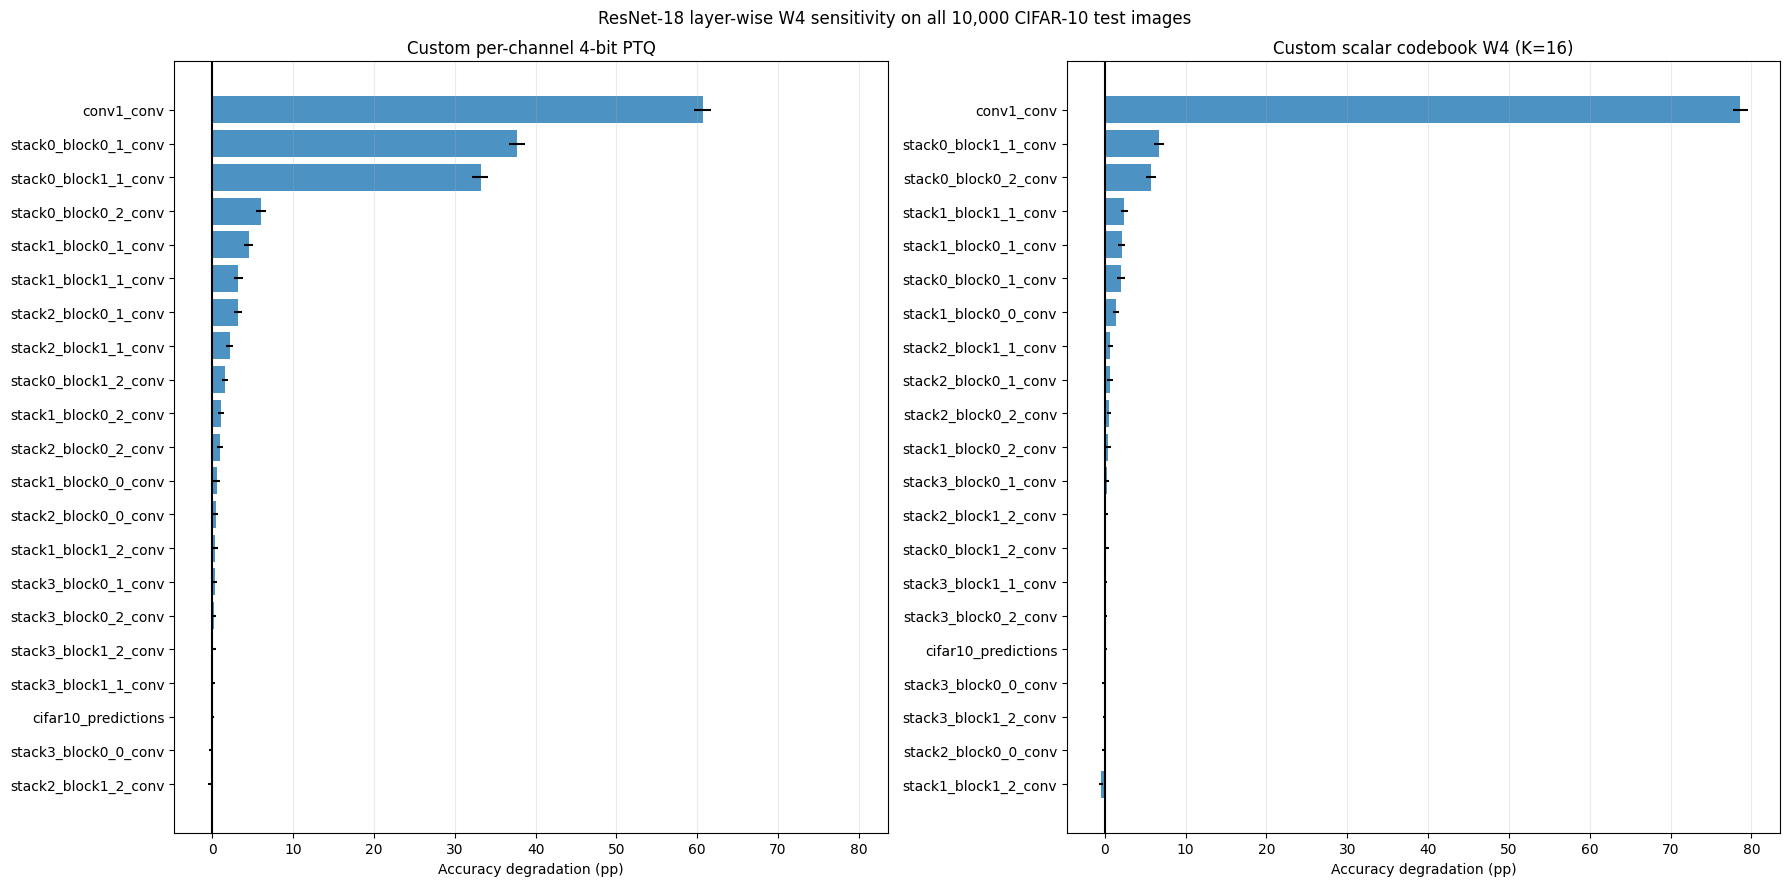

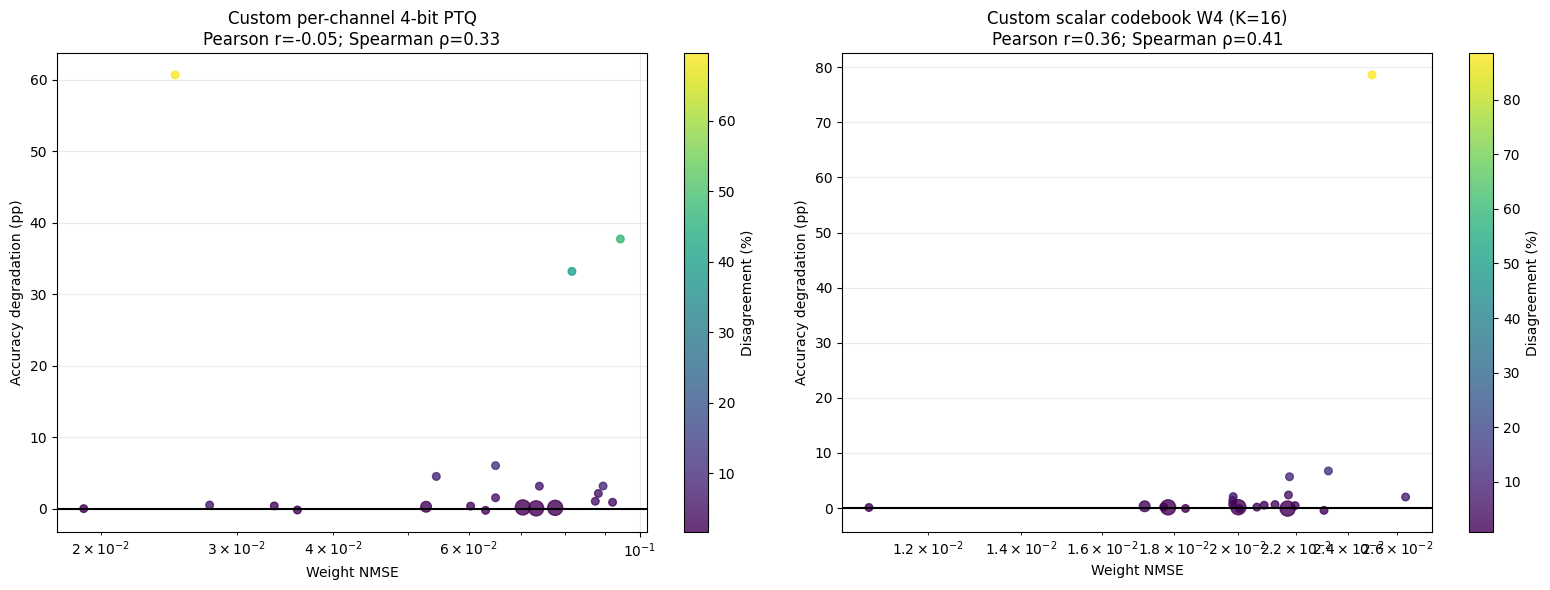

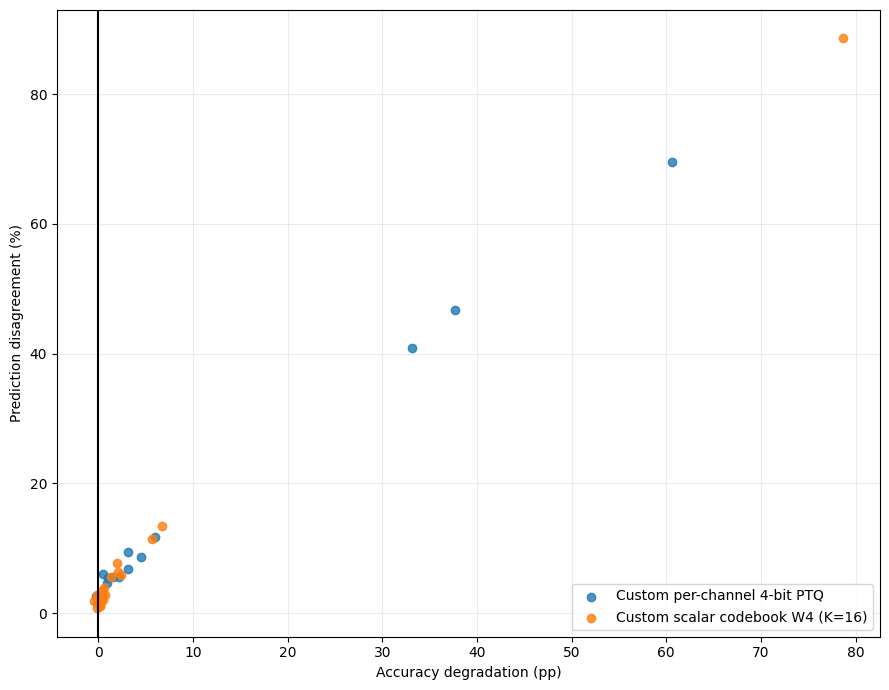

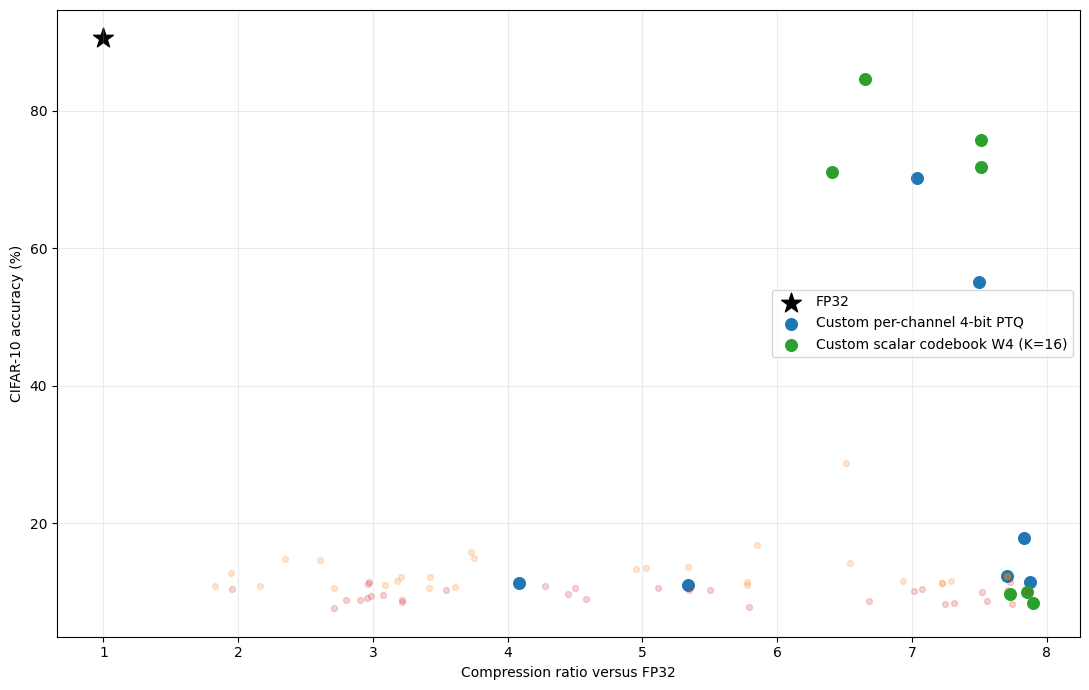

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharex=True)
for axis, (method, label) in zip(axes, METHODS.items()):
    group = ranked_results[ranked_results.method == method].sort_values("accuracy_degradation_pp")
    lower = np.maximum(0, group.accuracy_degradation_pp - group.bootstrap_ci_low_pp)
    upper = np.maximum(0, group.bootstrap_ci_high_pp - group.accuracy_degradation_pp)
    axis.barh(group.layer, group.accuracy_degradation_pp, xerr=[lower, upper], alpha=0.8)
    axis.axvline(0, color="black"); axis.set_title(label); axis.set_xlabel("Accuracy degradation (pp)"); axis.grid(axis="x", alpha=0.25)
fig.suptitle("ResNet-18 layer-wise W4 sensitivity on all 10,000 CIFAR-10 test images")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "figure1_layer_sensitivity_w4.png", dpi=180, bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for axis, (method, label) in zip(axes, METHODS.items()):
    group = layerwise_results[layerwise_results.method == method]
    scatter = axis.scatter(group.weight_nmse, group.accuracy_degradation_pp, s=np.maximum(30, group.parameter_count / 20_000), c=group.prediction_disagreement_percent, cmap="viridis", alpha=0.8)
    corr = correlation_table[(correlation_table.method == method) & (correlation_table.error_metric == "weight_nmse") & (correlation_table.response_metric == "accuracy_degradation_pp")].iloc[0]
    axis.set_xscale("log"); axis.axhline(0, color="black"); axis.set_xlabel("Weight NMSE"); axis.set_ylabel("Accuracy degradation (pp)")
    axis.set_title(f"{label}\nPearson r={corr.pearson_r:.2f}; Spearman ρ={corr.spearman_rho:.2f}"); axis.grid(alpha=0.25); fig.colorbar(scatter, ax=axis, label="Disagreement (%)")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "figure2_error_vs_sensitivity_w4.png", dpi=180, bbox_inches="tight"); plt.show()

fig, axis = plt.subplots(figsize=(9, 7))
for method, label in METHODS.items():
    group = layerwise_results[layerwise_results.method == method]
    axis.scatter(group.accuracy_degradation_pp, group.prediction_disagreement_percent, label=label, alpha=0.8)
axis.axvline(0, color="black"); axis.set_xlabel("Accuracy degradation (pp)"); axis.set_ylabel("Prediction disagreement (%)"); axis.legend(); axis.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "figure3_accuracy_vs_disagreement_w4.png", dpi=180, bbox_inches="tight"); plt.show()

fig, axis = plt.subplots(figsize=(11, 7)); axis.scatter([1], [fp32_accuracy * 100], marker="*", s=220, color="black", label="FP32")
for method, label in METHODS.items():
    group = nonrandom_results[nonrandom_results.method == method]
    axis.scatter(group.compression_ratio_vs_fp32, group.accuracy_percent, s=70, label=label)
    random_group = configuration_results[(configuration_results.method == method) & configuration_results.configuration.str.startswith("random_")]
    axis.scatter(random_group.compression_ratio_vs_fp32, random_group.accuracy_percent, s=18, alpha=0.2)
axis.set_xlabel("Compression ratio versus FP32"); axis.set_ylabel("CIFAR-10 accuracy (%)"); axis.legend(); axis.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "figure4_accuracy_compression_w4.png", dpi=180, bbox_inches="tight"); plt.show()

## 11. Save W4 tables and reproducibility metadata

In [15]:
ranked_results.to_csv(OUTPUT_DIR / "final_ranked_layer_sensitivity.csv", index=False)
candidate_table.to_csv(OUTPUT_DIR / "common_tensor_coverage.csv", index=False)
metadata = {
    "model_checkpoint": str(MODEL_PATH), "checkpoint_modified_time": MODEL_PATH.stat().st_mtime,
    "dataset": "CIFAR-10 official complete test split", "test_images": NUM_TEST_IMAGES,
    "methods": METHODS, "ptq": {"bits": NUM_BITS, "symmetric": True, "per_channel": PTQ_PER_CHANNEL},
    "codebook": {"assignment_bits": NUM_BITS, "codebook_size": CODEBOOK_SIZE, "vector_dim": CODEBOOK_VECTOR_DIM, "dtype": str(CODEBOOK_DTYPE), "iterations": CODEBOOK_ITERATIONS},
    "common_quantized_tensors": len(candidate_table), "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
    "random_control_repetitions": RANDOM_CONTROL_REPETITIONS, "top_k_values": TOP_K_VALUES,
    "storage_note": "Sub-byte assignments are theoretical packed storage; PTQ scale and codebook overhead are included.",
    "activations_quantized": False, "fake_quantization_used": False,
    "selection_bias_warning": "Selective configurations are exploratory because ranking and evaluation use the same test split.",
    "tensorflow_version": tf.__version__, "keras_version": keras.__version__, "scipy_version": scipy.__version__,
    "python_version": sys.version, "hardware": platform.platform(), "cache_version": CACHE_VERSION,
}
(OUTPUT_DIR / "run_metadata.json").write_text(json.dumps(metadata, indent=2, default=str))
print(f"W4 results saved under: {OUTPUT_DIR}")

W4 results saved under: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_4bit_layer_sensitivity


# W4 versus W8 comparison using Notebook 17's saved data

Run the preceding W4 experiment first. Notebook 17 must also have completed and saved its `layerwise_sensitivity_all_methods.csv` and `selective_quantization_all_configurations.csv` files. Comparison is performed only after confirming identical tensor paths and the same FP32 baseline.

In [16]:
eight_layer_path = EIGHT_BIT_OUTPUT_DIR / "layerwise_sensitivity_all_methods.csv"
eight_config_path = EIGHT_BIT_OUTPUT_DIR / "selective_quantization_all_configurations.csv"
if not eight_layer_path.exists() or not eight_config_path.exists():
    raise FileNotFoundError("Notebook 17's saved 8-bit tables are missing. Run Notebook 17 completely first.")

four_layers = ranked_results.copy()
eight_layers = pd.read_csv(eight_layer_path)
eight_layers["method_family"] = eight_layers.method.map({"ptq_w8": "ptq", "codebook_w8": "codebook"})
eight_layers["bit_width"] = 8
assert eight_layers.method_family.notna().all(), "Unexpected method identifiers in Notebook 17."
assert set(eight_layers.tensor) == set(four_layers.tensor), "W4 and W8 tensor coverage differs."
assert np.isclose(eight_layers.fp32_accuracy_percent.iloc[0], fp32_accuracy * 100), "FP32 baselines differ."

eight_ranked = eight_layers.sort_values(
    ["method", "accuracy_degradation_pp", "prediction_disagreement_percent"], ascending=[True, False, False]
).copy()
eight_ranked["sensitivity_rank"] = eight_ranked.groupby("method").cumcount() + 1

comparison_columns = [
    "method_family", "tensor", "layer", "layer_type", "parameter_count",
    "quantized_accuracy_percent", "accuracy_degradation_pp",
    "prediction_disagreement_percent", "weight_mse", "weight_nmse",
    "weight_sqnr_db", "sensitivity_rank",
]
four_compare = four_layers[comparison_columns].rename(columns={
    c: f"{c}_w4" for c in comparison_columns if c not in {"method_family", "tensor"}
})
eight_compare = eight_ranked[comparison_columns].rename(columns={
    c: f"{c}_w8" for c in comparison_columns if c not in {"method_family", "tensor"}
})
layer_bit_comparison = four_compare.merge(eight_compare, on=["method_family", "tensor"], validate="one_to_one")
layer_bit_comparison["additional_w4_degradation_pp"] = layer_bit_comparison.accuracy_degradation_pp_w4 - layer_bit_comparison.accuracy_degradation_pp_w8
layer_bit_comparison["additional_w4_disagreement_percent"] = layer_bit_comparison.prediction_disagreement_percent_w4 - layer_bit_comparison.prediction_disagreement_percent_w8
layer_bit_comparison["rank_change_w4_minus_w8"] = layer_bit_comparison.sensitivity_rank_w4 - layer_bit_comparison.sensitivity_rank_w8
layer_bit_comparison = layer_bit_comparison.sort_values(["method_family", "accuracy_degradation_pp_w4"], ascending=[True, False])
layer_bit_comparison.to_csv(OUTPUT_DIR / "layer_sensitivity_w4_vs_w8.csv", index=False)
display(layer_bit_comparison)

,method_family,tensor,layer_w4,layer_type_w4,parameter_count_w4,quantized_accuracy_percent_w4,accuracy_degradation_pp_w4,prediction_disagreement_percent_w4,weight_mse_w4,weight_nmse_w4,...,quantized_accuracy_percent_w8,accuracy_degradation_pp_w8,prediction_disagreement_percent_w8,weight_mse_w8,weight_nmse_w8,weight_sqnr_db_w8,sensitivity_rank_w8,additional_w4_degradation_pp,additional_w4_disagreement_percent,rank_change_w4_minus_w8
0,codebook,conv1_conv/kernel,conv1_conv,Conv2D,9408,11.85,78.62,88.57,0.001380,0.024961,...,89.95,0.52,2.77,0.000002,0.000038,44.201276,1,7.810000e+01,85.80,0
1,codebook,stack0_block1_1_conv/kernel,stack0_block1_1_conv,Conv2D,36864,83.73,6.74,13.34,0.001677,0.023226,...,90.51,-0.04,0.66,0.000005,0.000068,41.691679,13,6.780000e+00,12.68,-11
2,codebook,stack0_block0_2_conv/kernel,stack0_block0_2_conv,Conv2D,36864,84.78,5.69,11.38,0.001327,0.021784,...,90.53,-0.06,0.41,0.000004,0.000070,41.523516,15,5.750000e+00,10.97,-12
3,codebook,stack1_block1_1_conv/kernel,stack1_block1_1_conv,Conv2D,147456,88.09,2.38,5.81,0.001423,0.021746,...,90.51,-0.04,0.43,0.000006,0.000089,40.516208,14,2.420000e+00,5.38,-10
4,codebook,stack1_block0_1_conv/kernel,stack1_block0_1_conv,Conv2D,73728,88.39,2.08,6.32,0.001341,0.019853,...,90.55,-0.08,0.45,0.000005,0.000077,41.111991,18,2.160000e+00,5.87,-13
5,codebook,stack0_block0_1_conv/kernel,stack0_block0_1_conv,Conv2D,36864,88.46,2.01,7.66,0.001805,0.026380,...,90.56,-0.09,0.82,0.000005,0.000071,41.458210,20,2.100000e+00,6.84,-14
6,codebook,stack1_block0_0_conv/kernel,stack1_block0_0_conv,Conv2D,8192,89.07,1.40,5.59,0.001459,0.019837,...,90.55,-0.08,0.31,0.000004,0.000048,43.161627,19,1.480000e+00,5.28,-12
7,codebook,stack2_block1_1_conv/kernel,stack2_block1_1_conv,Conv2D,589824,89.78,0.69,2.73,0.001080,0.019834,...,90.56,-0.09,0.31,0.000012,0.000213,36.716568,21,7.800000e-01,2.42,-13
8,codebook,stack2_block0_1_conv/kernel,stack2_block0_1_conv,Conv2D,294912,89.83,0.64,3.79,0.001259,0.021269,...,90.53,-0.06,0.23,0.000005,0.000093,40.323772,16,7.000000e-01,3.56,-7
9,codebook,stack2_block0_2_conv/kernel,stack2_block0_2_conv,Conv2D,589824,89.95,0.52,2.00,0.001142,0.020892,...,90.42,0.05,0.13,0.000008,0.000151,38.197566,2,4.700000e-01,1.87,8


## 12. Compact W4-versus-W8 comparison tables

In [17]:
comparison_summary_rows = []
for family, group in layer_bit_comparison.groupby("method_family"):
    rank_corr = spearmanr(group.sensitivity_rank_w4, group.sensitivity_rank_w8)
    for bits in (4, 8):
        suffix = f"w{bits}"
        comparison_summary_rows.append({
            "method_family": family, "bit_width": bits, "layers": len(group),
            "mean_accuracy_degradation_pp": float(group[f"accuracy_degradation_pp_{suffix}"].mean()),
            "maximum_accuracy_degradation_pp": float(group[f"accuracy_degradation_pp_{suffix}"].max()),
            "mean_prediction_disagreement_percent": float(group[f"prediction_disagreement_percent_{suffix}"].mean()),
            "maximum_prediction_disagreement_percent": float(group[f"prediction_disagreement_percent_{suffix}"].max()),
            "median_weight_nmse": float(group[f"weight_nmse_{suffix}"].median()),
            "w4_w8_sensitivity_rank_spearman_rho": float(rank_corr.statistic),
            "w4_w8_sensitivity_rank_spearman_p": float(rank_corr.pvalue),
        })
comparison_summary = pd.DataFrame(comparison_summary_rows)
comparison_summary.to_csv(OUTPUT_DIR / "layer_sensitivity_w4_vs_w8_summary.csv", index=False)

top_comparison = (layer_bit_comparison.groupby("method_family", group_keys=False).head(5)[[
    "method_family", "tensor", "quantized_accuracy_percent_w4", "quantized_accuracy_percent_w8",
    "accuracy_degradation_pp_w4", "accuracy_degradation_pp_w8",
    "prediction_disagreement_percent_w4", "prediction_disagreement_percent_w8",
    "weight_nmse_w4", "weight_nmse_w8", "sensitivity_rank_w4", "sensitivity_rank_w8",
]])
top_comparison.to_csv(OUTPUT_DIR / "top5_sensitive_layers_w4_vs_w8.csv", index=False)
display(comparison_summary); display(top_comparison)

,method_family,bit_width,layers,mean_accuracy_degradation_pp,maximum_accuracy_degradation_pp,mean_prediction_disagreement_percent,maximum_prediction_disagreement_percent,median_weight_nmse,w4_w8_sensitivity_rank_spearman_rho,w4_w8_sensitivity_rank_spearman_p
0,codebook,4,21,4.841429,78.62,7.969524,88.57,0.020643,-0.292208,0.198673
1,codebook,8,21,-0.007143,0.52,0.367619,2.77,0.000089,-0.292208,0.198673
2,ptq,4,21,7.430000,60.65,11.462857,69.60,0.064963,-0.093506,0.686840
3,ptq,8,21,0.007143,0.53,0.511429,3.17,0.000217,-0.093506,0.686840


,method_family,tensor,quantized_accuracy_percent_w4,quantized_accuracy_percent_w8,accuracy_degradation_pp_w4,accuracy_degradation_pp_w8,prediction_disagreement_percent_w4,prediction_disagreement_percent_w8,weight_nmse_w4,weight_nmse_w8,sensitivity_rank_w4,sensitivity_rank_w8
0,codebook,conv1_conv/kernel,11.85,89.95,78.62,0.52,88.57,2.77,0.024961,0.000038,1,1
1,codebook,stack0_block1_1_conv/kernel,83.73,90.51,6.74,-0.04,13.34,0.66,0.023226,0.000068,2,13
2,codebook,stack0_block0_2_conv/kernel,84.78,90.53,5.69,-0.06,11.38,0.41,0.021784,0.000070,3,15
3,codebook,stack1_block1_1_conv/kernel,88.09,90.51,2.38,-0.04,5.81,0.43,0.021746,0.000089,4,14
4,codebook,stack1_block0_1_conv/kernel,88.39,90.55,2.08,-0.08,6.32,0.45,0.019853,0.000077,5,18
21,ptq,conv1_conv/kernel,29.82,89.94,60.65,0.53,69.60,3.17,0.024963,0.000201,1,1
22,ptq,stack0_block0_1_conv/kernel,52.75,90.52,37.72,-0.05,46.68,1.79,0.094292,0.000446,2,17
23,ptq,stack0_block1_1_conv/kernel,57.28,90.53,33.19,-0.06,40.83,0.87,0.081596,0.000276,3,18
24,ptq,stack0_block0_2_conv/kernel,84.42,90.55,6.05,-0.08,11.79,0.69,0.064963,0.000211,4,19
25,ptq,stack1_block0_1_conv/kernel,85.93,90.66,4.54,-0.19,8.58,0.54,0.054435,0.000170,5,21


In [18]:
eight_configs = pd.read_csv(eight_config_path)
eight_configs["method_family"] = eight_configs.method.map({"ptq_w8": "ptq", "codebook_w8": "codebook"})
eight_full = eight_configs[eight_configs.configuration == "full_w8"].copy(); eight_full["bit_width"] = 8
four_full = configuration_results[configuration_results.configuration == "full_w4"].copy()
full_model_bit_comparison = pd.concat([four_full, eight_full], ignore_index=True, sort=False)
full_model_bit_comparison = full_model_bit_comparison[[
    "method_family", "bit_width", "correct_predictions", "test_images",
    "accuracy_percent", "accuracy_degradation_pp", "prediction_disagreement_percent",
    "parameter_mib", "compression_ratio_vs_fp32", "memory_reduction_percent",
]].sort_values(["method_family", "bit_width"])
full_model_bit_comparison.to_csv(OUTPUT_DIR / "full_model_w4_vs_w8.csv", index=False)
display(full_model_bit_comparison)

,method_family,bit_width,correct_predictions,test_images,accuracy_percent,accuracy_degradation_pp,prediction_disagreement_percent,parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent
1,codebook,4,843,10000,8.43,82.04,91.21,5.401802,7.903140,87.346802
3,codebook,8,9025,10000,90.25,0.22,2.96,10.748268,3.971914,74.823223
0,ptq,4,1156,10000,11.56,78.91,88.10,5.418869,7.878249,87.306824
2,ptq,8,8988,10000,89.88,0.59,3.79,10.746109,3.972712,74.828281


## 13. W4-versus-W8 comparison figures

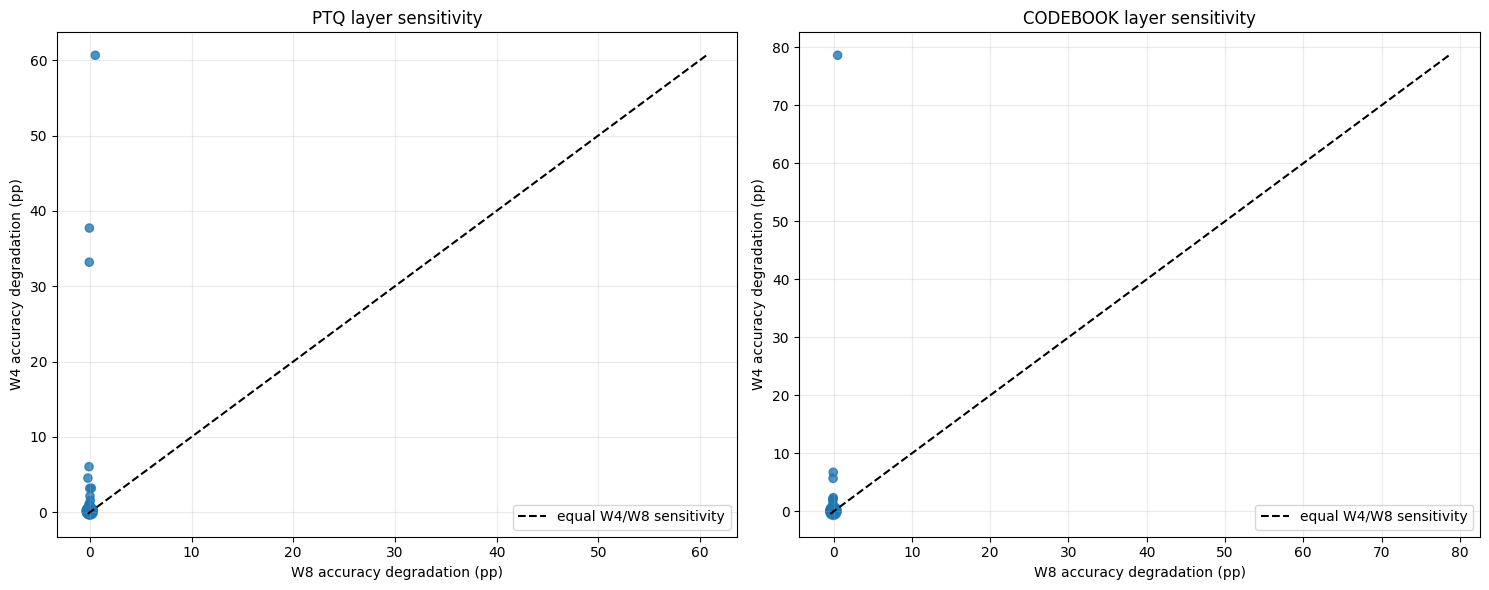

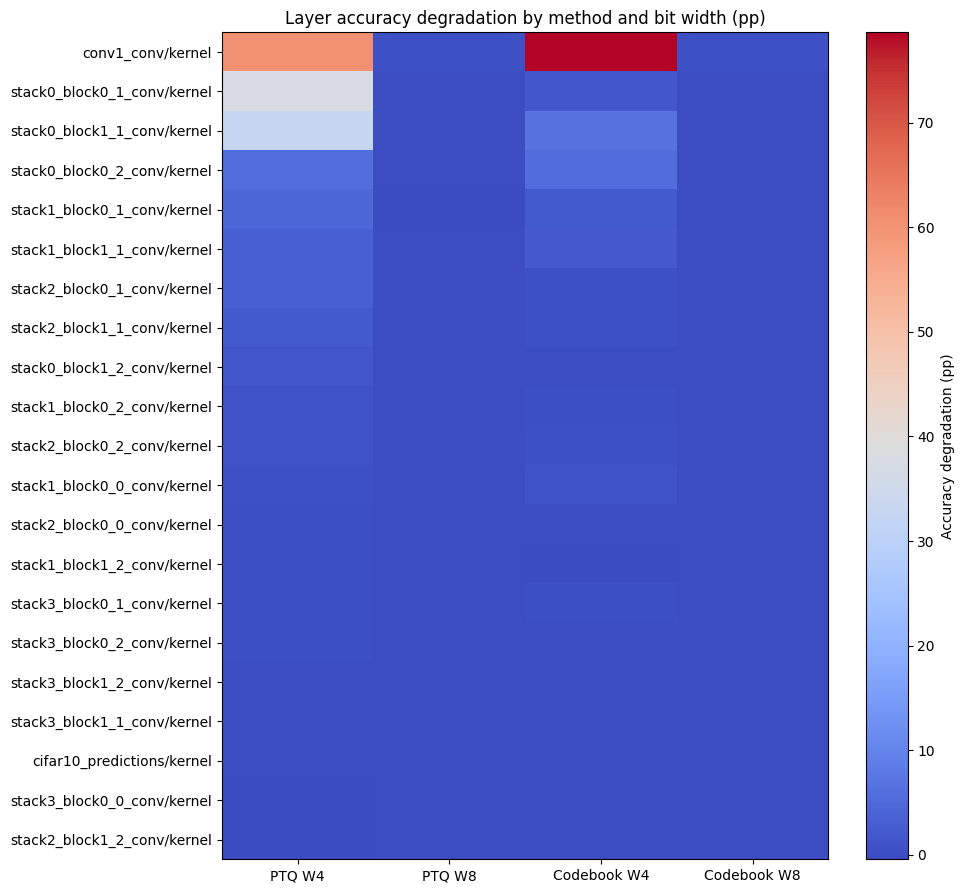

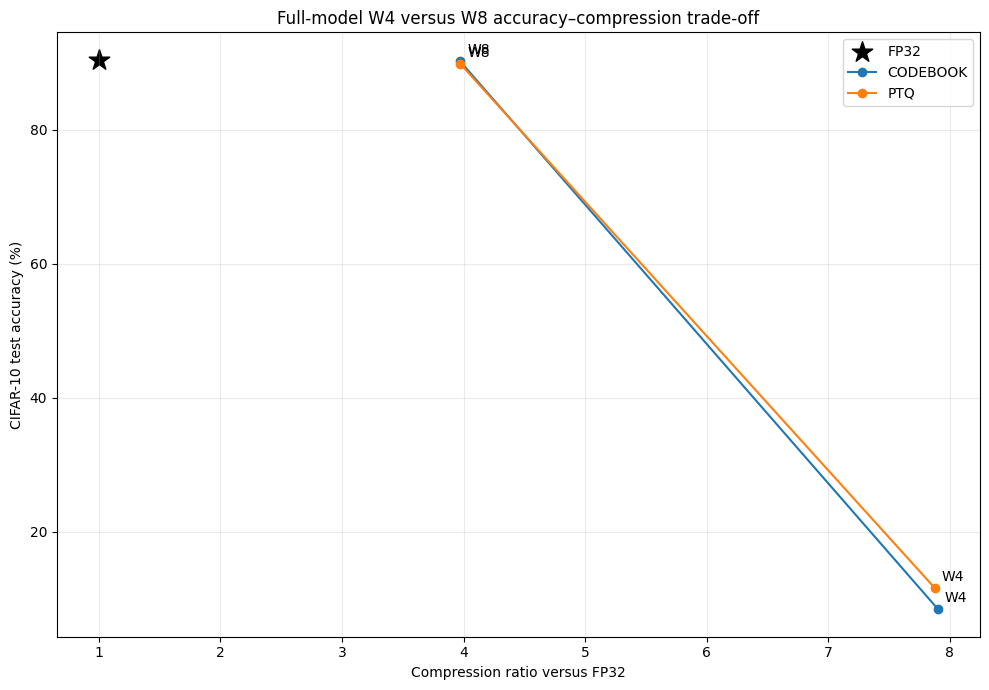

All W4 and W4-versus-W8 tables and figures saved under: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_4bit_layer_sensitivity


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, family in zip(axes, ("ptq", "codebook")):
    group = layer_bit_comparison[layer_bit_comparison.method_family == family]
    axis.scatter(group.accuracy_degradation_pp_w8, group.accuracy_degradation_pp_w4, s=np.maximum(35, group.parameter_count_w4 / 20_000), alpha=0.8)
    limits = [min(group.accuracy_degradation_pp_w8.min(), group.accuracy_degradation_pp_w4.min()), max(group.accuracy_degradation_pp_w8.max(), group.accuracy_degradation_pp_w4.max())]
    axis.plot(limits, limits, "--", color="black", label="equal W4/W8 sensitivity")
    axis.set_xlabel("W8 accuracy degradation (pp)"); axis.set_ylabel("W4 accuracy degradation (pp)"); axis.set_title(f"{family.upper()} layer sensitivity"); axis.grid(alpha=0.25); axis.legend()
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "figure5_layer_degradation_w4_vs_w8.png", dpi=180, bbox_inches="tight"); plt.show()

heatmap = layer_bit_comparison.pivot(index="tensor", columns="method_family", values=["accuracy_degradation_pp_w4", "accuracy_degradation_pp_w8"])
heatmap.columns = [f"{family}_{metric.rsplit('_', 1)[-1]}" for metric, family in heatmap.columns]
heatmap = heatmap[["ptq_w4", "ptq_w8", "codebook_w4", "codebook_w8"]]
heatmap = heatmap.loc[layer_bit_comparison[layer_bit_comparison.method_family == "ptq"].sort_values("accuracy_degradation_pp_w4", ascending=False).tensor]
fig, axis = plt.subplots(figsize=(10, max(8, len(heatmap) * 0.43)))
image = axis.imshow(heatmap.to_numpy(), aspect="auto", cmap="coolwarm")
axis.set_xticks(range(len(heatmap.columns)), ["PTQ W4", "PTQ W8", "Codebook W4", "Codebook W8"]); axis.set_yticks(range(len(heatmap.index)), heatmap.index)
axis.set_title("Layer accuracy degradation by method and bit width (pp)"); fig.colorbar(image, ax=axis, label="Accuracy degradation (pp)")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "figure6_layer_sensitivity_heatmap_w4_w8.png", dpi=180, bbox_inches="tight"); plt.show()

fig, axis = plt.subplots(figsize=(10, 7)); axis.scatter([1], [fp32_accuracy * 100], marker="*", s=240, color="black", label="FP32")
for family, group in full_model_bit_comparison.groupby("method_family"):
    group = group.sort_values("bit_width"); axis.plot(group.compression_ratio_vs_fp32, group.accuracy_percent, "o-", label=family.upper())
    for row in group.itertuples(index=False): axis.annotate(f"W{row.bit_width}", (row.compression_ratio_vs_fp32, row.accuracy_percent), xytext=(5, 5), textcoords="offset points")
axis.set_xlabel("Compression ratio versus FP32"); axis.set_ylabel("CIFAR-10 test accuracy (%)"); axis.set_title("Full-model W4 versus W8 accuracy–compression trade-off"); axis.grid(alpha=0.25); axis.legend()
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "figure7_full_model_w4_w8_tradeoff.png", dpi=180, bbox_inches="tight"); plt.show()
print(f"All W4 and W4-versus-W8 tables and figures saved under: {OUTPUT_DIR}")

## Interpretation rules

- A positive degradation means the isolated quantized layer reduced accuracy relative to the same FP32 baseline.
- W4 is expected to produce larger reconstruction error than W8, but the functional effect need not be monotonic for every tensor.
- One-layer effects cannot be added to predict the full-model result because simultaneous perturbations interact.
- Equal accuracy does not imply equal predictions; use disagreement and paired outcome counts.
- W4 storage is a theoretical packed estimate. The reconstructed Keras model does not demonstrate native 4-bit runtime speed or physical in-memory packing.
- Selective configurations are exploratory because the same test split ranks and evaluates protected layers.